# 06 — Make-take fees: an exchange designing the incentives of its maker

An exchange cannot quote.  It can only change what quoting pays and then live
with what the maker does next, which makes fee design a Stackelberg problem: the
exchange moves first with a contract, the maker re-optimises, and the exchange's
revenue is whatever the maker's new behaviour produces.  This is the structure of
El Euch, Mastrolia, Rosenbaum and Tan, in the tractable case where the contract
is a rebate $z$ per fill.

The agent's problem is chapter 05 with $\delta+z$ captured instead of $\delta$,
so $\delta^\star = 1/k - z - \Delta_q$ and the coupling of the linear system is
scaled by $e^{kz}$.  Setting $z=0$ has to give chapter 05 back exactly, which is
the check this notebook opens with.

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hfx.viz import subplots, use_style, colour_for, tick_regime
from hfx.pipeline.results import panel, curves, curve, symbol_days
use_style()
P = panel(); C = curves()
DAY = "2019-01-30"
print(f"{len(P)} symbol-days, {P.symbol.nunique()} symbols, {P.date.nunique()} dates")

84 symbol-days, 12 symbols, 7 dates


In [2]:
from hfx.design.maketake import maker_solution, exchange_gain, optimal_rebate
from hfx.mm.glft import stationary_quotes

A, k, phi, Q = 1.0, 1.5, 0.02, 6
base = maker_solution(A, k, phi, Q, rebate=0.0)
bid, ask, _v = stationary_quotes(A, k, 0.0, 0.0, Q, phi=phi)
assert np.allclose(base.bid[:-1], bid[:-1]) and np.allclose(base.ask[1:], ask[1:])
print("a zero rebate reproduces chapter 05 exactly")
print(base)

a zero rebate reproduces chapter 05 exactly
MakerSolution(z=0.0000, spread=1.5306, fills/s=0.6832, gain=0.4217)


## What a rebate buys

The identity worth knowing: buying at inventory $q$ and selling back from $q+1$
captures $\delta^b(q)+\delta^a(q+1) = 2/k - 2z$, with the inventory terms
cancelling.  The whole rebate reaches the price of a round trip, whatever the
maker's risk aversion.  What the skew decides is *when* it earns it -- individual
quotes move by different amounts, so a flat rebate tilts the schedule instead of
translating it.

z = 0: round trip = [1.33333333]   (2/k - 2z = 1.3333)
z = 0.2: round trip = [0.93333333]   (2/k - 2z = 0.9333)


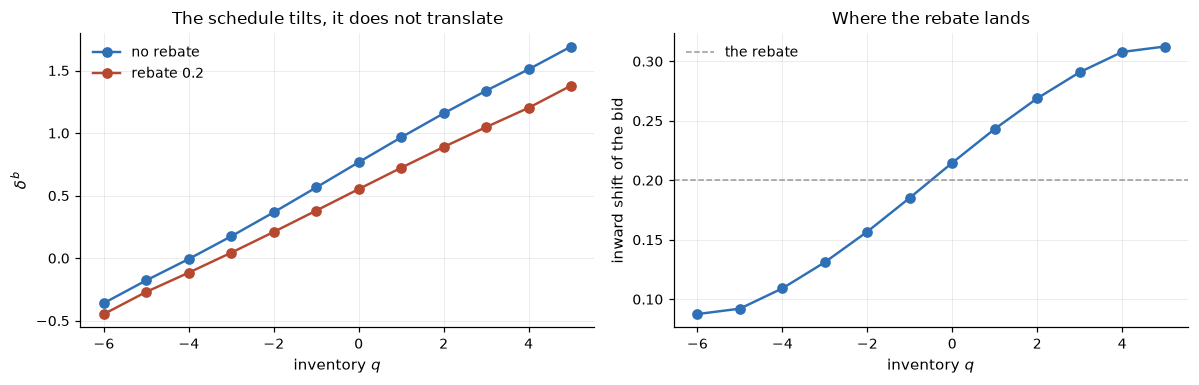

In [3]:
z = 0.2
paid = maker_solution(A, k, phi, Q, rebate=z)
inv = np.arange(-Q, Q + 1)
for sol, label in [(base, "z = 0"), (paid, f"z = {z}")]:
    print(f"{label}: round trip = {np.unique(np.round(sol.bid[:-1] + sol.ask[1:], 10))}"
          f"   (2/k - 2z = {2/k - 2*sol.rebate:.4f})")
fig, axes = subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(inv[:-1], base.bid[:-1], "o-", label="no rebate")
axes[0].plot(inv[:-1], paid.bid[:-1], "o-", label=f"rebate {z}")
axes[0].set_xlabel("inventory $q$"); axes[0].set_ylabel(r"$\delta^b$")
axes[0].set_title("The schedule tilts, it does not translate"); axes[0].legend()
axes[1].plot(inv[:-1], base.bid[:-1] - paid.bid[:-1], "o-")
axes[1].axhline(z, color="0.6", ls="--", lw=1, label="the rebate")
axes[1].set_xlabel("inventory $q$"); axes[1].set_ylabel("inward shift of the bid")
axes[1].set_title("Where the rebate lands"); axes[1].legend()
plt.tight_layout()

## The exchange's problem

The exchange charges takers $c$ and pays the maker $z$, so it earns $(c-z)$ per
trade at whatever rate the maker's new quotes produce.  Because the fill rate at
the optimum behaves like $e^{kz}$, the first-order condition gives a rebate that
does not depend on the maker's risk aversion, its inventory limit, or the
volatility:

$$z^\star = c - \frac1k.$$

In [4]:
rows = []
for c in [0.5 / k, 1.0 / k, 2.0 / k, 3.0 / k]:
    z_star, sol, grid, obj = optimal_rebate(A, k, phi, Q, taker_fee=c)
    rows.append({"taker fee c": c, "z*": z_star, "c - 1/k": c - 1 / k,
                 "spread": 2 * sol.spread, "spread at z=0": 2 * base.spread,
                 "fills/s": sol.fill_rate, "fills/s at z=0": base.fill_rate,
                 "exchange gain": exchange_gain(sol, c),
                 "maker gain": sol.gain})
print(pd.DataFrame(rows).round(4).to_string(index=False))

 taker fee c      z*  c - 1/k  spread  spread at z=0  fills/s  fills/s at z=0  exchange gain  maker gain
      0.3333 -0.3017  -0.3333  4.3727         3.0613   0.4261          0.6832         0.2705      0.2574
      0.6667  0.0233   0.0000  2.9609         3.0613   0.7085          0.6832         0.4558      0.4380
      1.3333  0.6783   0.6667  0.1886         3.0613   1.9468          0.6832         1.2752      1.2415
      2.0000  1.3400   1.3333 -2.5353         3.0613   5.3257          0.6832         3.5149      3.4654


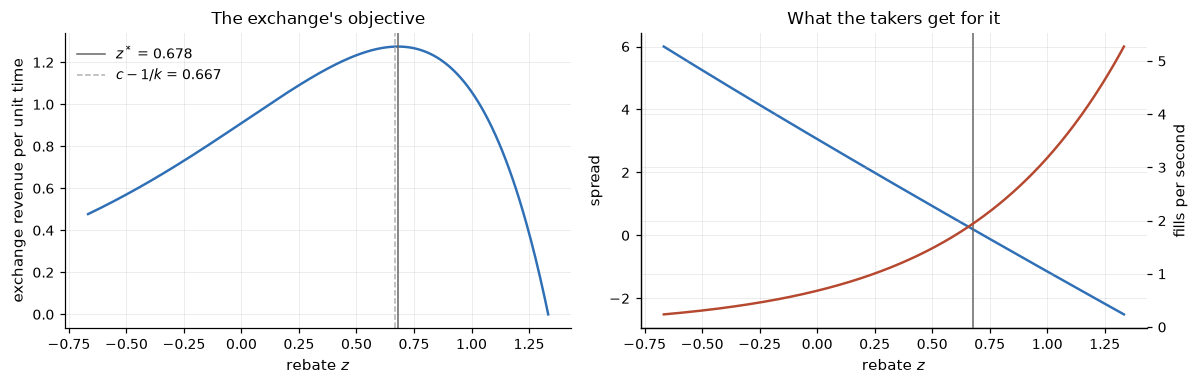

In [5]:
fig, axes = subplots(1, 2, figsize=(11, 3.6))
c = 2.0 / k
z_star, sol, grid, obj = optimal_rebate(A, k, phi, Q, taker_fee=c)
spreads = np.array([2 * maker_solution(A, k, phi, Q, float(zz)).spread for zz in grid])
rates = np.array([maker_solution(A, k, phi, Q, float(zz)).fill_rate for zz in grid])
axes[0].plot(grid, obj)
axes[0].axvline(z_star, color="0.4", lw=1, label=f"$z^*$ = {z_star:.3f}")
axes[0].axvline(c - 1 / k, color="0.7", ls="--", lw=1, label=f"$c-1/k$ = {c - 1/k:.3f}")
axes[0].set_xlabel("rebate $z$"); axes[0].set_ylabel("exchange revenue per unit time")
axes[0].set_title("The exchange's objective"); axes[0].legend()
axes[1].plot(grid, spreads, label="maker's spread")
ax2 = axes[1].twinx(); ax2.plot(grid, rates, color="#b5482f", label="fills per second")
axes[1].axvline(z_star, color="0.4", lw=1); axes[1].set_xlabel("rebate $z$")
axes[1].set_ylabel("spread"); ax2.set_ylabel("fills per second")
axes[1].set_title("What the takers get for it")
plt.tight_layout()

## A regulator instead of a shareholder

The same machinery answers a different question if the objective changes.  Give
the principal a taste for market quality -- a penalty on the spread the takers
face -- and the optimal rebate rises: the exchange is being paid to buy a
tighter market.

In [6]:
rows = []
c = 2.0 / k
for w in [0.0, 0.5, 1.0, 2.0]:
    z_w, sol_w, _g, _o = optimal_rebate(A, k, phi, Q, taker_fee=c, spread_weight=w)
    rows.append({"spread weight": w, "z*": z_w, "spread": 2 * sol_w.spread,
                 "fills/s": sol_w.fill_rate, "maker gain": sol_w.gain,
                 "exchange revenue": exchange_gain(sol_w, c)})
out = pd.DataFrame(rows)
print(out.round(4).to_string(index=False))
assert out["z*"].is_monotonic_increasing and out["spread"].is_monotonic_decreasing

 spread weight     z*  spread  fills/s  maker gain  exchange revenue
           0.0 0.6783  0.1886   1.9468      1.2415            1.2752
           0.5 0.9183 -0.8078   2.8087      1.8059            1.1656
           1.0 1.0633 -1.4050   3.5019      2.2616            0.9455
           2.0 1.2533 -2.1825   4.6712      3.0328            0.3737


Two warnings the model gives for free.  A rebate large enough makes the
maker quote *through* the mid -- it is being paid more to trade than the spread
is worth, and it will trade at a loss on the price to collect the rebate; that is
the standard criticism of aggressive maker-taker pricing, and here it falls out
of a first-order condition rather than an anecdote.  And the participation
constraint runs the other way: an exchange that pays too little loses the maker
altogether, so the optimum is a corner, not an interior point.

What the model does *not* have is competition between venues, which is the first
thing a real fee schedule is designed against.  The single-exchange answer
$z^\star = c - 1/k$ is a benchmark to reason from, not a recommendation.